In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Bütün sınıfların (Forest, River vb.) olduğu ANA KLASÖR yolunu buraya yapıştır. (veya EUROSAT_DIR ortam değişkenini ayarla)
dataset_path = os.environ.get("EUROSAT_DIR", "EuroSAT_RGB/Data")

def load_all_data(directory_path, img_size=(64, 64)):
    """Tüm resimleri tek seferde okur."""
    images = []
    labels = []
    
    if not os.path.exists(directory_path):
        print(f"HATA: '{directory_path}' bulunamadı!")
        return np.array([]), np.array([]), []

    class_names = sorted([d for d in os.listdir(directory_path) if os.path.isdir(os.path.join(directory_path, d))])
    class_map = {name: i for i, name in enumerate(class_names)}
    
    print(f"Sınıflar okunuyor: {class_names}")
    
    for class_name in class_names:
        class_path = os.path.join(directory_path, class_name)
        file_list = os.listdir(class_path)
        # print(f" - {class_name} yükleniyor ({len(file_list)} resim)...")
        
        for img_name in file_list:
            try:
                img_path = os.path.join(class_path, img_name)
                img = Image.open(img_path).convert('RGB')
                img = img.resize(img_size)
                images.append(np.array(img))
                labels.append(class_map[class_name])
            except:
                pass 
                
    X = np.array(images) / 255.0                 # Piksel değerlerini 0-255 aralığından 0-1 arasına sıkıştırır (Normalizasyon).
    y = np.array(labels)
    return X, y, class_names

# 1. BÜTÜN VERİYİ YÜKLE
print("--- Tüm Veriler Okunuyor (Biraz zaman alabilir) ---")
X_all, y_all, class_names = load_all_data(dataset_path)

if len(X_all) > 0:
    print(f"Toplam Resim Sayısı: {X_all.shape[0]}")

    # 2. %80 EĞİTİM - %20 TEST OLARAK AYIR (Otomatik ve Rastgele)
    # stratify=y_all: Her sınıftan eşit oranda (örn: %20 Orman, %20 Nehir) test setine koyar. Çok önemlidir.
    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y_all, 
        test_size=0.20, 
        random_state=42, 
        stratify=y_all
    )

    print(f"\n--- Veri Ayrıştırma Tamamlandı ---")
    print(f"Eğitim Seti (%80): {X_train.shape[0]} adet")
    print(f"Test Seti   (%20): {X_test.shape[0]} adet")
else:
    print("HATA: Hiç resim yüklenemedi. Klasör yolunu kontrol et.")

--- Tüm Veriler Okunuyor (Biraz zaman alabilir) ---
Sınıflar okunuyor: ['Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Residential', 'River', 'SeaLake']
Toplam Resim Sayısı: 17850

--- Veri Ayrıştırma Tamamlandı ---
Eğitim Seti (%80): 14280 adet
Test Seti   (%20): 3570 adet


In [2]:
# ==========================================
# MODEL 1: RANDOM FOREST
# ==========================================
print("--- Model 1: Random Forest Eğitiliyor ---")

# Düzleştirme
nsamples, nx, ny, nc = X_train.shape
X_train_flat = X_train.reshape((nsamples, nx*ny*nc))

nsamples_test, _, _, _ = X_test.shape
X_test_flat = X_test.reshape((nsamples_test, nx*ny*nc))

# Eğitim
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_flat, y_train)

# Test
y_pred_rf = rf_model.predict(X_test_flat)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"✅ Random Forest Başarısı: %{acc_rf*100:.2f}")
cm_rf = confusion_matrix(y_test, y_pred_rf)

--- Model 1: Random Forest Eğitiliyor ---
✅ Random Forest Başarısı: %73.22


In [ ]:
# ==========================================
# MODEL 2: CNN + BATCH NORMALIZATION
# ==========================================
print("\n--- Model 2: CNN (Derin Öğrenme) Hazırlanıyor ---")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kullanılan Cihaz: {device}")

# PyTorch Formatına Çevir (N, 3, 64, 64)
X_train_cnn = torch.tensor(X_train, dtype=torch.float32).permute(0, 3, 1, 2).to(device)
y_train_cnn = torch.tensor(y_train, dtype=torch.long).to(device)
X_test_cnn  = torch.tensor(X_test, dtype=torch.float32).permute(0, 3, 1, 2).to(device)
y_test_cnn  = torch.tensor(y_test, dtype=torch.long).to(device)

train_loader = DataLoader(TensorDataset(X_train_cnn, y_train_cnn), batch_size=64, shuffle=True)

# CNN Mimarisi
class SatelliteCNN(nn.Module):
    def __init__(self, num_classes):
        super(SatelliteCNN, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # Resimdeki kenar ve özellikleri yakalamak için 32 farklı filtre uygular.
            nn.BatchNorm2d(32),                          # Sayıları dengeleyerek eğitimin daha hızlı ve kararlı olmasını sağlar.
            nn.ReLU(),                                   # Negatif değerleri sıfırlayarak modelin öğrenmesini sağlar.
            nn.MaxPool2d(2, 2),                          # Resmi yarı yarıya küçülterek işlem yükünü azaltır ve önemli detayları saklar.
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),                                # Kare matris şeklindeki veriyi tek bir uzun satır haline getirir.
            nn.Linear(128 * 8 * 8, 512),                 # Toplanan 8192 adet ipucunu 512 nöronluk bir karar havuzuna dönüştürür.
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_cnn = SatelliteCNN(len(class_names)).to(device) # Modeli oluşturur ve işlemi hızlandırmak için Ekran Kartına (GPU) gönderir.
criterion = nn.CrossEntropyLoss()            # Tahmin ile gerçek cevap arasındaki hatayı (Loss) hesaplayan fonksiyondur.
optimizer = optim.Adam(model_cnn.parameters(), lr=0.001) # Hatayı azaltmak için modelin ayarlarını (ağırlıklarını) güncelleyen algoritmadır.

# Eğitim Döngüsü
epochs = 15
loss_list = []
print(f"Eğitim Başlıyor ({epochs} Epoch)...")

for epoch in range(epochs):
    model_cnn.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model_cnn(inputs)
        loss = criterion(outputs, labels)
        loss.backward()                              # Hatanın modelin hangi parçasından kaynaklandığını geriye doğru hesaplar (Türev alma).
        optimizer.step()                             # Hesaplanan hataya göre modelin ağırlıklarını günceller (Asıl öğrenme anı).
        running_loss += loss.item()
    
    avg_loss = running_loss / len(train_loader)
    loss_list.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")

# Test
model_cnn.eval()
with torch.no_grad():
    outputs = model_cnn(X_test_cnn)
    _, predicted = torch.max(outputs, 1)
    y_pred_cnn = predicted.cpu().numpy()

acc_cnn = accuracy_score(y_test, y_pred_cnn)
print(f"\n✅ CNN Model Başarısı: %{acc_cnn*100:.2f}")
cm_cnn = confusion_matrix(y_test, y_pred_cnn)


--- Model 2: CNN (Derin Öğrenme) Hazırlanıyor ---
Kullanılan Cihaz: cpu
Eğitim Başlıyor (15 Epoch)...
Epoch 1/15 | Loss: 1.0049
Epoch 2/15 | Loss: 0.5748
Epoch 3/15 | Loss: 0.4870
Epoch 4/15 | Loss: 0.4151
Epoch 5/15 | Loss: 0.3765
Epoch 6/15 | Loss: 0.3326
Epoch 7/15 | Loss: 0.2962
Epoch 8/15 | Loss: 0.2832
Epoch 9/15 | Loss: 0.2437
Epoch 10/15 | Loss: 0.2659
Epoch 11/15 | Loss: 0.2311
Epoch 12/15 | Loss: 0.2060
Epoch 13/15 | Loss: 0.1878
Epoch 14/15 | Loss: 0.1938
Epoch 15/15 | Loss: 0.1492

✅ CNN Model Başarısı: %89.75


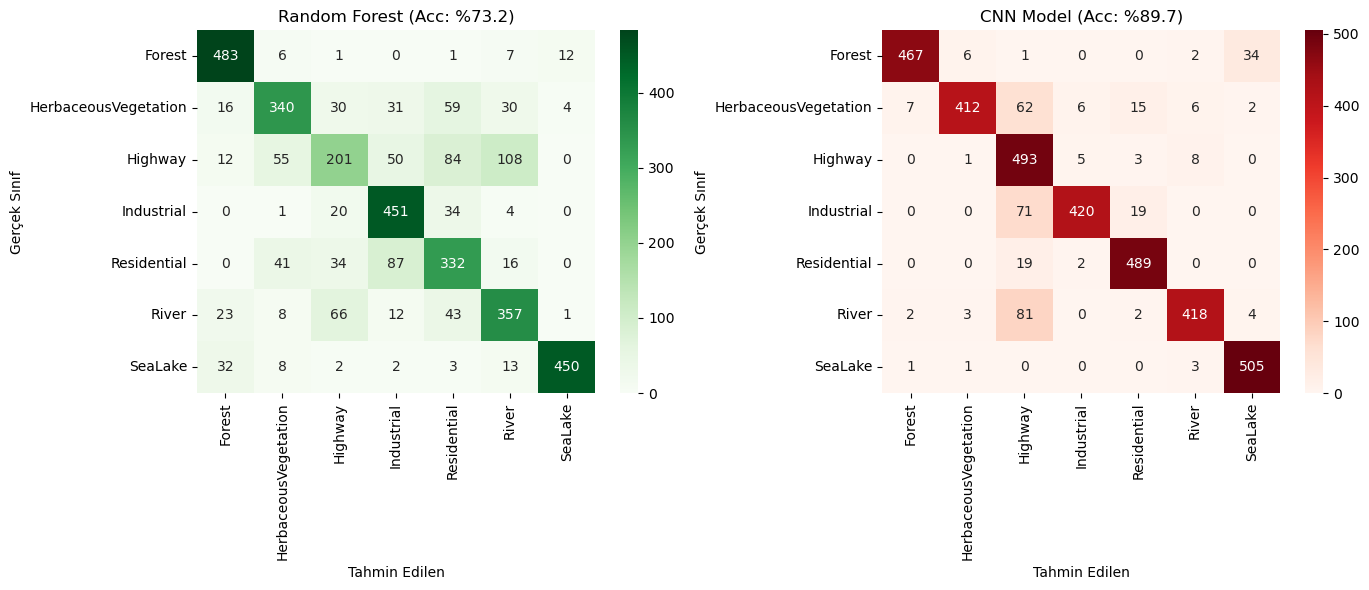

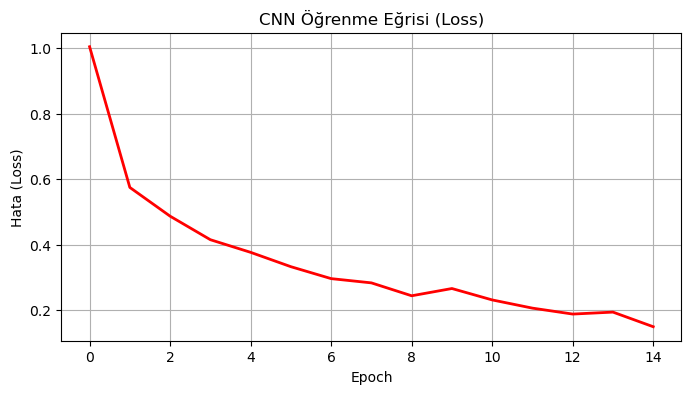

In [5]:
# ==========================================
# SONUÇLARI KARŞILAŞTIRMA
# ==========================================
plt.figure(figsize=(14, 6))

# 1. Random Forest Grafiği
plt.subplot(1, 2, 1)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title(f"Random Forest (Acc: %{acc_rf*100:.1f})")
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Sınıf')

# 2. CNN Grafiği
plt.subplot(1, 2, 2)
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names)
plt.title(f"CNN Model (Acc: %{acc_cnn*100:.1f})")
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Sınıf')

plt.tight_layout()
plt.show()

# CNN Eğitim Kaybı Grafiği
plt.figure(figsize=(8, 4))
plt.plot(loss_list, label='CNN Loss', color='red', linewidth=2)
plt.title("CNN Öğrenme Eğrisi (Loss)")
plt.xlabel("Epoch")
plt.ylabel("Hata (Loss)")
plt.grid(True)
plt.show()

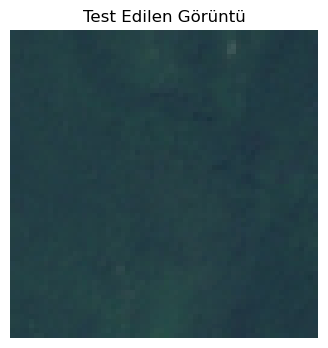

📊 TAHMİN SONUÇLARI:
----------------------------------------
🌲 Random Forest Diyor ki:  Forest
🧠 CNN (Yapay Zeka) Diyor ki: Forest (Güven: %100.0)
----------------------------------------
✅ İki model de aynı fikirde!


In [ ]:
# ==========================================
# FOTOĞRAF TEST ETME FONKSİYONU
# ==========================================

def test_tek_resim(resim_yolu):
    """
    Verilen fotoğrafı okur, ekranda gösterir ve
    hem Random Forest hem de CNN modeliyle tahmin yapar.
    """
    if not os.path.exists(resim_yolu):
        print("❌ HATA: Dosya bulunamadı! Yolu kontrol edin.")
        return

    # 1. Resmi Aç ve Göster
    try:
        img_org = Image.open(resim_yolu).convert('RGB')
        plt.figure(figsize=(4,4))
        plt.imshow(img_org)
        plt.axis('off')
        plt.title("Test Edilen Görüntü")
        plt.show()
        
        # 2. Modelleme İçin Hazırla (64x64 boyutlandır ve normalize et)
        img = img_org.resize((64, 64))
        img_array = np.array(img) / 255.0
        
        # --- Random Forest Tahmini ---
        img_flat = img_array.reshape(1, -1) # Düzleştir
        rf_tahmin_idx = rf_model.predict(img_flat)[0]
        rf_sinif = class_names[rf_tahmin_idx]
        
        # --- CNN Tahmini ---
        # Tensöre çevir: (1, 3, 64, 64)
        img_tensor = torch.tensor(img_array, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(device)
        
        model_cnn.eval()
        with torch.no_grad():
            cikti = model_cnn(img_tensor)
            olasiliklar = torch.nn.functional.softmax(cikti, dim=1)
            cnn_tahmin_idx = torch.argmax(olasiliklar).item()
            cnn_guven = olasiliklar[0][cnn_tahmin_idx].item() * 100
            cnn_sinif = class_names[cnn_tahmin_idx]

        # 3. Sonuçları Yazdır
        print("📊 TAHMİN SONUÇLARI:")
        print("-" * 40)
        print(f"🌲 Random Forest Diyor ki:  {rf_sinif}")
        print(f"🧠 CNN (Yapay Zeka) Diyor ki: {cnn_sinif} (Güven: %{cnn_guven:.1f})")
        print("-" * 40)
        
        if cnn_sinif == rf_sinif:
            print("✅ İki model de aynı fikirde!")
        else:
            print("⚠️ Modellerin kafası karışık. Genellikle CNN daha doğrudur.")
            
    except Exception as e:
        print(f"Bir hata oluştu: {e}")

# --- NASIL KULLANILIR? ---
# Aşağıdaki parantez içine test etmek istediğin fotoğrafın yolunu yaz.
# Örnek: "orman_fotografi.jpg"

test_tek_resim("EuroSAT_RGB/Test/Residential/chrome_fgGzBcf3r3.png")